<a href="https://colab.research.google.com/github/eahernandezrangel-art/LabAvanzado/blob/main/Proyecto1_InferenciaBayesiana_suceptibilidad_magnetica_suero_anemico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Proyecto 1: Inferencia Bayesiana en datos de suceptibilidad magnetica en suero anemico

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from scipy.stats import shapiro
from scipy.stats import levene


In [30]:
#Cargamos los datos de suceptibilidad
df=pd.read_excel('SuceptibilidadMagnetica_suero.xlsx')
df.head()

,Muestra,Grupo,Subgrupo,Repeticion,chi
0,A1,anemico,IMSS,1,-1.611765459139e-06
1,A1,anemico,IMSS,2,-1.746079247400e-06
2,A1,anemico,IMSS,3,-1.611765459139e-06
3,A1,anemico,IMSS,4,-1.746079247400e-06
4,A1,anemico,IMSS,5,-1.611765459139e-06


In [31]:
#Revisamos la estructura de los datos
print('Grupos:')
print(df['Grupo'].value_counts())
print('Subgrupos:')
print(df['Subgrupo'].value_counts())

Grupos:
Grupo
anemico    255
asume      120
sano        90
Name: count, dtype: int64
Subgrupos:
Subgrupo
IMSS    345
UG      120
Name: count, dtype: int64


In [32]:
#La base se compone de  5 columnas en la que se encuentra la muestra, grrupo, subgrupo,repeticion y chi
#que es la suceptibiliada calculada a traves de la masa aparente y el campo, en este se analizaron
# 17 muestras que corresponden a la etiqueta A para pacientes anemicos obtenidos del IMSS ya con
#prueba hematografica y diagnostico y 14 con la etiqueta S que se dividin en dos grupos sano y asume,
#que indica su obtencion los pacientes sanos son pacientes obtenido de IMSS teniendo estos una prueba hematografica
# mientras que los pacientes del grupo asume son estudiantes voluntarios que donaron muestras sin una prueba hematografica
#A cada muestra se le realizaron 15 mediciones por magno-gavimetria.


#Para observar las diferencias entre estos grupos primero veamos lo que nos dice la estadistica descriptiva

for grupo, datos in df.groupby('Grupo'):
    print('Grupo:', grupo)
    print(
        'media=',
        '{:.12e}'.format(datos['chi'].mean()),
    )
    print(
        'mediana=',
        '{:.12e}'.format(datos['chi'].median()),
    )
    print(
        'desviacion estandar=',
        '{:.12e}'.format(datos['chi'].std()),
    )



Grupo: anemico
media= -1.311098378326e-06
mediana= -1.343534426531e-06
desviacion estandar= 2.119358302775e-07
Grupo: asume
media= -1.405282046782e-06
mediana= -1.344363647282e-06
desviacion estandar= 1.794673166106e-07
Grupo: sano
media= -1.635555625655e-06
mediana= -1.611876598773e-06
desviacion estandar= 1.969203244972e-07


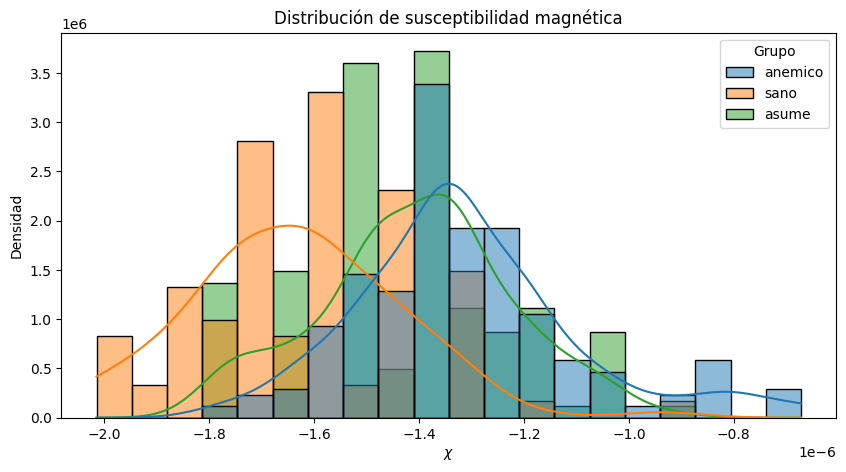

In [33]:
#A simple vista podemos observar por la mediana qe el anemico y e lque asume sanidad son practicamente iguales
#para verlo mejor veamos el histograma
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='chi', hue='Grupo', bins=20, stat='density',common_norm=False, kde=True)
plt.xlabel(r'$\chi$')
plt.ylabel('Densidad')
plt.title('Distribución de susceptibilidad magnética')
plt.show()

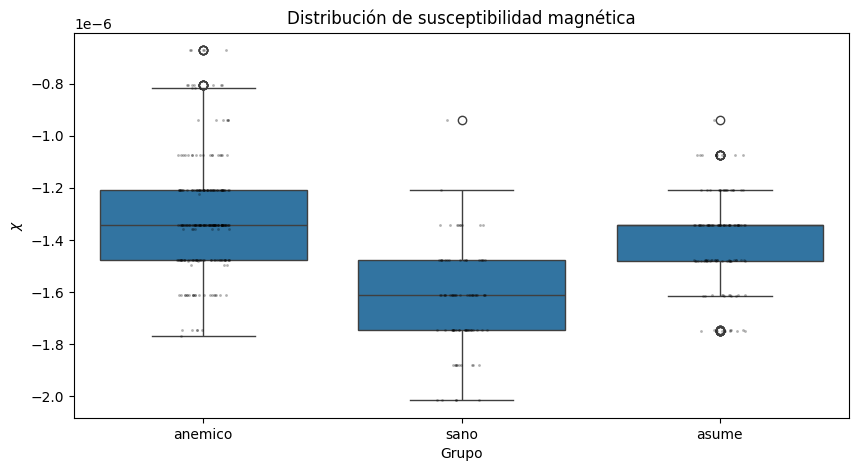

In [35]:
# viendo el histograma , observamos que la distribucion del grupo de control de los sanos , el clinicamente evaluado,
#se encuentra  desplazado hacia valores mas negativos respecto a los anemicos y los autodeclarados sanos, de echo tambien podemos
#observar lo visto anteriosmente en la mediana siendo que la distribucion entre estos dos ultimos grupos sugiere que existe mayor
# relacion entre estos grupos.

#Veamos ahora una grafica tipo cajas para ver el comportamiento de la media
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Grupo', y='chi')
sns.stripplot(data=df, x='Grupo', y='chi', jitter=True, color='black', alpha=0.3,size=2)
plt.xlabel("Grupo")
plt.ylabel(r'$\chi$')
plt.title("Distribución de susceptibilidad magnética")
plt.show()


In [43]:
#De las graficas de caja, mantiene los mismos resultados observados en la distribucion, los sanos
# siguen siendo loa mas diamagneticos. En este grafico podemos observar con mas claridad el paerecido
#entre las medias de los grupos anemicos y autodeclarados.

#Para que esta diferencia o parecidos vistos queden de manera mas clara y dado que las mediciones tanto de suceptibilidad
#como el que sea en un tejido biologico presentan variabilidad experimental haremos
#un analisis estadistico frecuentista  para evaluar si existen diferencias observables entre los grupos sano, anémico y autodeclarado sano.

#Porque las distribuciones no parecen perfectamente normales, iniciamos por hacer una prueba
#Mann-Whitney una prueba no parametrica,  para ello primero debemos juntar datos en un grupo por paciente y no como medicion
# ya que corremos el riesgo que al realizar la prueba tome cada medcion como un paciente

resumen_paciente = (
    df.groupby(["Muestra","Grupo"])["chi"]
      .mean()
      .reset_index()
)

resumen_paciente.head()

#Vemos que efectivamente ese contando paciente y no medicion
resumen_paciente["Grupo"].value_counts()

,count
Grupo,
anemico,17
asume,8
sano,6


In [53]:
#definimos ahora a los pacientes
anemico_p = resumen_paciente[
    resumen_paciente["Grupo"]=="anemico"
]["chi"]

sano_p = resumen_paciente[
    resumen_paciente["Grupo"]=="sano"
]["chi"]

asume_p = resumen_paciente[
    resumen_paciente["Grupo"]=="asume"
]["chi"]

In [45]:

#Aplicamos la prueba mann-whitney , en nuestros pacientes para identificar
# las diferencias o parecidos comparando entre grupos las medias

comparaciones = [
    ("Anemico vs Sano", anemico_p, sano_p),
    ("Anemico vs Autodeclarado", anemico_p, asume_p),
    ("Sano vs Autodeclarado", sano_p, asume_p)
]

resultados_mw_paciente = []

for nombre, g1, g2 in comparaciones:

    U, p = mannwhitneyu(
        g1,
        g2,
        alternative="two-sided"
    )

    resultados_mw_paciente.append(
        [nombre, U, p]
    )

mw_paciente = pd.DataFrame(
    resultados_mw_paciente,
    columns=["Comparacion","U","p"]
)

mw_paciente

,Comparacion,U,p
0,Anemico vs Sano,9.600000000000e+01,5.943713037535e-04
1,Anemico vs Autodeclarado,9.200000000000e+01,1.747340683725e-01
2,Sano vs Autodeclarado,5.000000000000e+00,1.265401265401e-02


In [48]:
#El mann-witney nuevamente nos mostro que estadisticamente por la comparacion entre la distribucion
#el grupo anemico y autodeclado sano no hay una diferencia, ahora veamos otra prueba estadistica  que explore
#la comparacion entre medias, primero vemos si existe una diferencia entre la varianzas

#Haremos una prueba de levene que tiene la Hipotesis del cuadrado de la varancias es igual entre ellas
stat, p = levene(anemico_p, sano_p, asume_p)
print('stat=%.3f, p=%.3f' % (stat, p))


stat=0.212, p=0.811


In [50]:
#La prueba levene nos arroja que no existe una diferencia significativa entre las varancias por lo que podriamos justificar el uso de una prueba t student para la comparacion de media,
#pero por el tamano de muestra conviene hacer una prueba t-Welch y no depender de la hipotesis
#de homocedasticidad

resultados_welch = []

for nombre, g1, g2 in comparaciones:

    t, p = ttest_ind(
        g1,
        g2,
        equal_var=False
    )
    resultados_welch.append(
        [nombre, t, p]
    )

welch = pd.DataFrame(
    resultados_welch,
    columns=["Comparacion","t","p"]
)

welch

,Comparacion,t,p
0,Anemico vs Sano,5.161425165642e+00,1.448578149449e-04
1,Anemico vs Autodeclarado,1.414690058609e+00,1.751655950925e-01
2,Sano vs Autodeclarado,-3.414922228977e+00,5.187660611049e-03


In [51]:
#La prueba welch nos vuelve a arrojar lo observado en las graficas y sigue siendo consistente
# con la prueba mann-whitney de que No existe evidencia suficiente para afirmar que las medias sean distintas.

#Ahora las pruebas estadisticas anteriores nos indican solamente que no ncontramos evidencia suficiente para afirmar una diferencia.
#Pero no nos dicen la suceptibilidad media mas probable de cada grupo,la incertidumbre de esta estimacion,
# que tan compatibles son relamente ambos grupos .

# La inferencia bayesiana permitirá investigar con mayor detalle el grado de compatibilidad entre ambas
#poblaciones mediante el estudio de las distribuciones posteriores de sus parámetros característicos.

#Empezamos por intalar librerias
! pip install emcee
!pip install corner



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.0 MB/s eta 0:00:00


In [61]:
import emcee
import corner

In [54]:
#Igualmente trabajamos con pacientes , entonces definimos grupos asi
resumen_paciente = (
    df.groupby(["Muestra","Grupo"])["chi"].mean().reset_index()
)

anemico_b= resumen_paciente[
    resumen_paciente["Grupo"]=="anemico"
]["chi"].values

sano_b = resumen_paciente[
    resumen_paciente["Grupo"]=="sano"
]["chi"].values

asume_b = resumen_paciente[
    resumen_paciente["Grupo"]=="asume"
]["chi"].values

#Vemos que efectivamente ese contando paciente y no medicion
resumen_paciente["Grupo"].value_counts()


,count
Grupo,
anemico,17
asume,8
sano,6


In [56]:
#Definimos el modelo bayesiano, empezamos por definir el prior
def log_prior(theta):
  mu_a,log_sig_a,mu_s,log_sig_s,mu_u, log_sig_u = theta
  #siendo u los autodeclarados
  sig_a=np.exp(log_sig_a)
  sig_s=np.exp(log_sig_s)
  sig_u=np.exp(log_sig_u)

  #Asignamos  rangos amplios para los prios, razonables para los valores de
  #suceptibilidad, que tenemos
  if(
      -3e-6<mu_a< 0 and
      -3e-6<mu_s< 0 and
      -3e-6<mu_u< 0 and
      1e-10<sig_a< 1e-5 and
      1e-10<sig_s< 1e-5 and
      1e-10<sig_u< 1e-5
  ):
    return 0.0
  return -np.inf

In [58]:
#Continuamos con el Likelihhod

def log_likelihood_normal(x, mu, sig):
  return -0.5*np.sum((x-mu)**2/sig**2 + np.log(2*np.pi*sig**2))

def log_likelihood(theta, anemico, sano, asume):
  mu_a,log_sig_a,mu_s,log_sig_s,mu_u, log_sig_u = theta
  sig_a=np.exp(log_sig_a)
  sig_s=np.exp(log_sig_s)
  sig_u=np.exp(log_sig_u)

  ll_a=log_likelihood_normal(anemico, mu_a, sig_a)
  ll_s=log_likelihood_normal(sano, mu_s, sig_s)
  ll_u=log_likelihood_normal(asume, mu_u, sig_u)

  return ll_a+ll_s+ll_u


In [60]:
#Ahora el posterior

def log_probability(theta, anemico, sano, asume):
  lp=log_prior(theta)
  if not np.isfinite(lp):
    return -np.inf
  return lp+log_likelihood(theta, anemico, sano, asume)

In [62]:
#Incializamos  las cadenas, empezamos tomando valores cercanos a los datos
mu_a0=np.mean(anemico_b)
mu_s0=np.mean(sano_b)
mu_u0=np.mean(asume_b)

sig_a0=np.std(anemico_b,ddof=1)
sig_s0=np.std(sano_b,ddof=1)
sig_u0=np.std(asume_b,ddof=1)

initial=np.array([mu_a0,np.log(sig_a0),mu_s0,np.log(sig_s0),mu_u0,np.log(sig_u0)])

ndim=6
nwalkers=48

pos= initial+1e-8*np.random.randn(nwalkers, ndim)

sampler= emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(anemico_b, sano_b, asume_b))


In [63]:
#Ahora corremos el MCMC
nsteps=600
sampler.run_mcmc(pos, nsteps, progress=True)


100%|██████████| 600/600 [00:01<00:00, 319.36it/s]


State([[-1.29715454e-06 -1.58363928e+01 -1.69507147e-06 -1.60697453e+01
  -1.41650957e-06 -1.61659069e+01]
 [-1.34862089e-06 -1.54327366e+01 -1.61567745e-06 -1.59202492e+01
  -1.41734087e-06 -1.53209235e+01]
 [-1.29766667e-06 -1.56764564e+01 -1.70370850e-06 -1.51708509e+01
  -1.37595895e-06 -1.56427914e+01]
 [-1.32405542e-06 -1.54910262e+01 -1.65814432e-06 -1.62394802e+01
  -1.52912646e-06 -1.55396662e+01]
 [-1.38643267e-06 -1.52280861e+01 -1.59553135e-06 -1.59299974e+01
  -1.39320328e-06 -1.60531712e+01]
 [-1.32997221e-06 -1.51071408e+01 -1.64826980e-06 -1.60319663e+01
  -1.44952583e-06 -1.58125756e+01]
 [-1.31102288e-06 -1.56336458e+01 -1.62715715e-06 -1.58238899e+01
  -1.36790018e-06 -1.60214990e+01]
 [-1.32888342e-06 -1.57497563e+01 -1.64684915e-06 -1.61293654e+01
  -1.36860886e-06 -1.58742943e+01]
 [-1.32440056e-06 -1.53368942e+01 -1.66572136e-06 -1.52161675e+01
  -1.40756537e-06 -1.61273392e+01]
 [-1.30702579e-06 -1.55266308e+01 -1.61975343e-06 -1.64193058e+01
  -1.43071954e-06 -

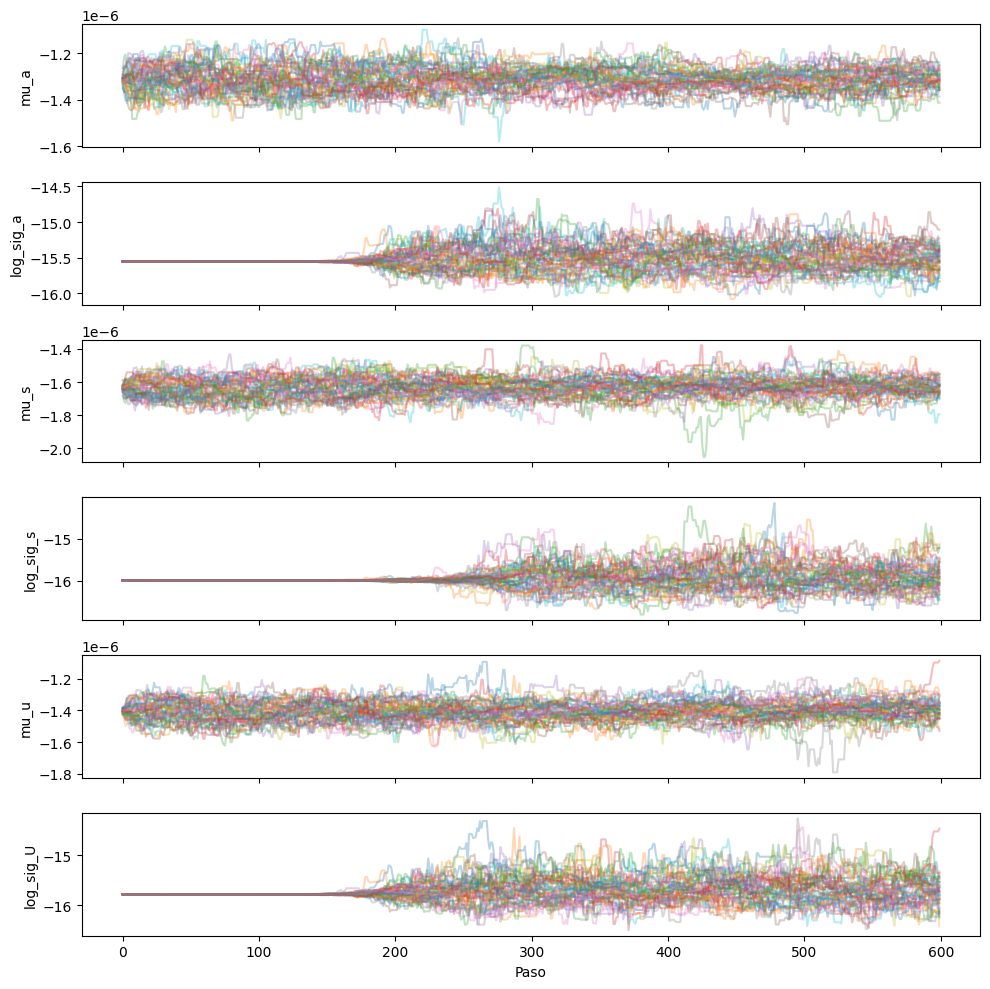

In [65]:
#Graficamos las cadenas para ver como se movieron los caminantes
samples_chain=sampler.get_chain()
labels=["mu_a","log_sig_a","mu_s","log_sig_s","mu_u",'log_sig_U']

fig,axes=plt.subplots(ndim, figsize=(10,10), sharex=True)
for i in range(ndim):
  axes[i].plot(samples_chain[:,:,i], alpha=0.3)
  axes[i].set_ylabel(labels[i])
axes[-1].set_xlabel('Paso')
plt.tight_layout()
plt.show()

In [69]:
#En las cadenas vemos que en el caso del logaritmo empiezan con un valor muy cercano
# al real, mientras que los mu se acercan a una estabilidad  al rededor del valor medio
# de la suceptibilidad

#Revisamos si se movio de manera correcta
print("iteraciones =", sampler.iteration)

print("shape =", sampler.get_chain().shape)

print("acceptance =",
      sampler.acceptance_fraction.mean())

iteraciones = 600
shape = (600, 48, 6)
acceptance = 0.525625


In [70]:
#Obtenemos las muestras posteriores
burnin=200
thin=5

#Aplanamos las cadenas
flat_samples=sampler.get_chain(discard=burnin, thin=thin, flat=True)
print(flat_samples.shape)

(3840, 6)


In [73]:
#Convertimos log_sigma  a sigma
posterior= flat_samples.copy()
posterior[:,1]=np.exp(posterior[:,1])
posterior[:,3]=np.exp(posterior[:,3])
posterior[:,5]=np.exp(posterior[:,5])

posterior_labels=[
    r"$\mu_{anemico}$",
    r"$\sigma_{anemico}$",
    r"$\mu_{sano}$",
    r"$\sigma_{sano}$",
    r"$\mu_{asume}$",
    r"$\sigma_{asume}$"
]

In [74]:
#Veamos los valores medios inferidos
mu_a=np.mean(posterior[:,0])
sig_a=np.mean(posterior[:,1])

mu_s=np.mean(posterior[:,2])
sig_s=np.mean(posterior[:,3])

mu_u=np.mean(posterior[:,4])
sig_u=np.mean(posterior[:,5])

print("mu_a=", np.mean(mu_a))
print("sig_a=", np.mean(sig_a))

print("mu_s=", np.mean(mu_s))
print("sig_s=", np.mean(sig_s))


print("mu_u=", np.mean(mu_u))
print("sig_u=", np.mean(sig_u))


mu_a= -1.3128218608245898e-06
sig_a= 1.8624902062218465e-07
mu_s= -1.631857392646496e-06
sig_s= 1.261249580414869e-07
mu_u= -1.403940944273384e-06
sig_u= 1.5836282611083059e-07


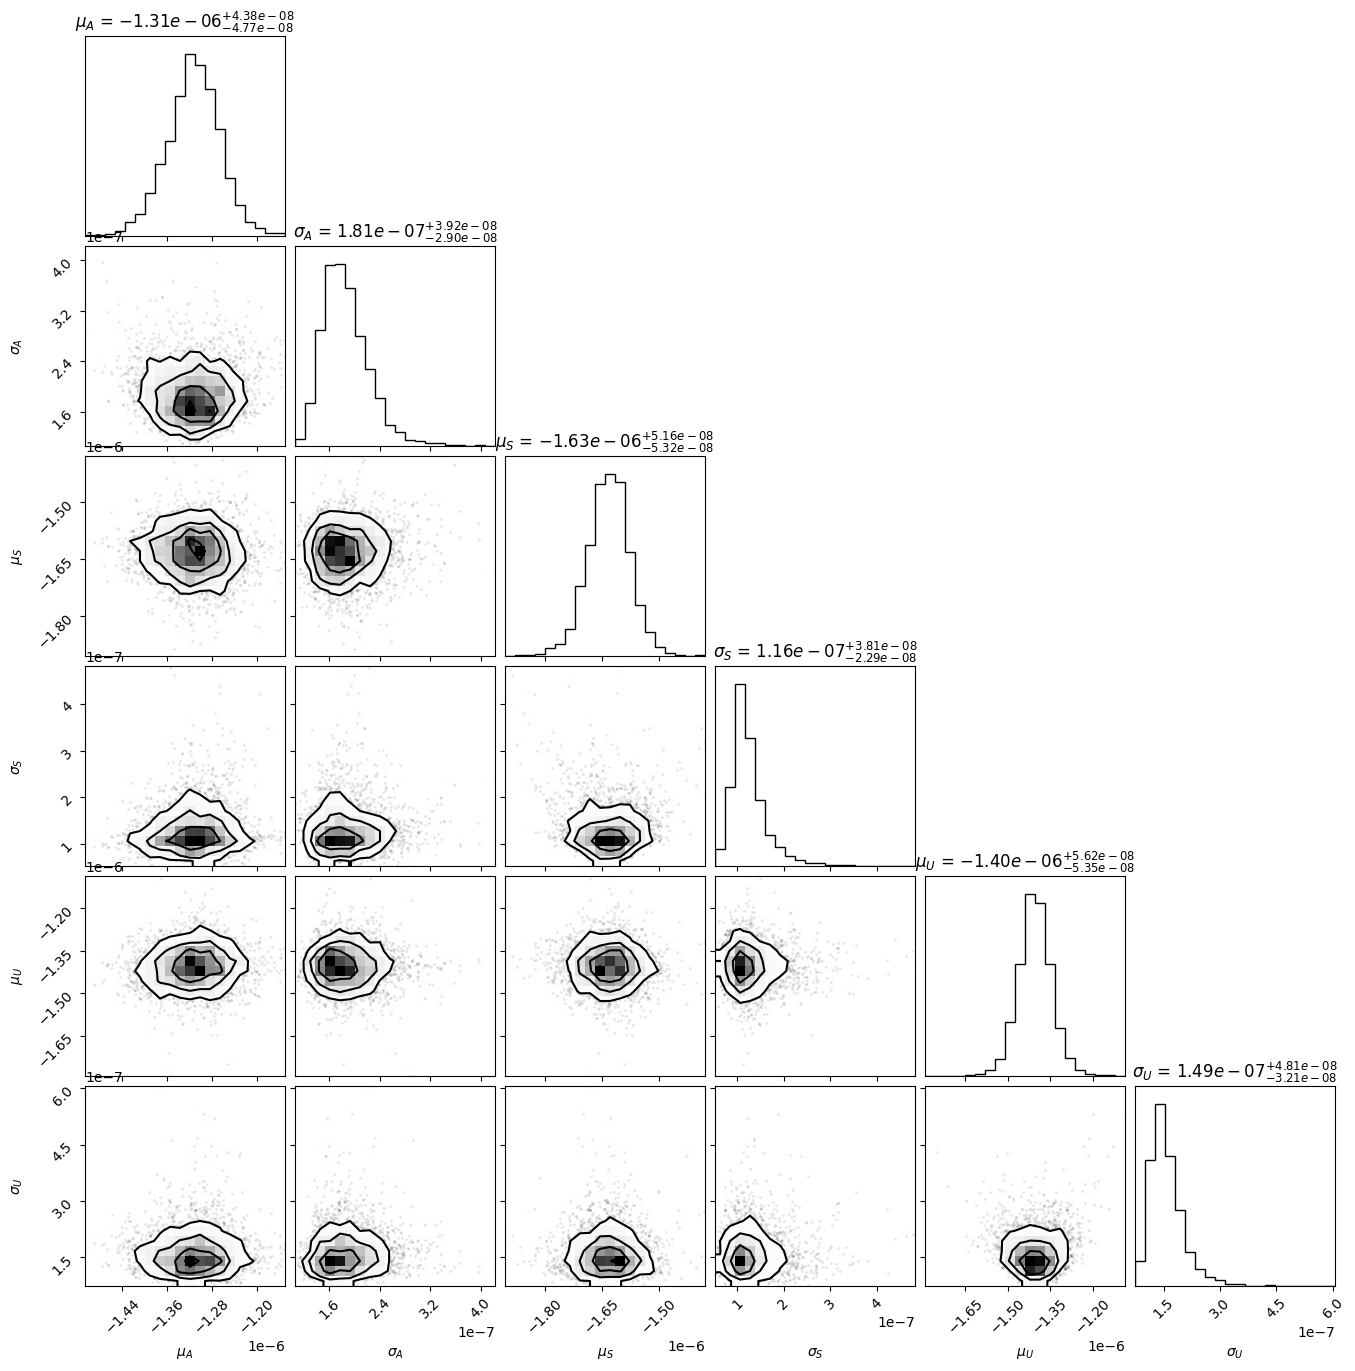

In [76]:
# Los valores medios nos vuelven afirmar que una mayor respuesta diamagnética
# se presnta por parte del grupo control clínicamente evaluado.

#Graficamos con corner

fig= corner.corner(posterior, labels=[r"$\mu_A$",
        r"$\sigma_A$",
        r"$\mu_S$",
        r"$\sigma_S$",
        r"$\mu_U$",
        r"$\sigma_U$"], show_titles=True, title_fmt='.2e'
)
plt.show()

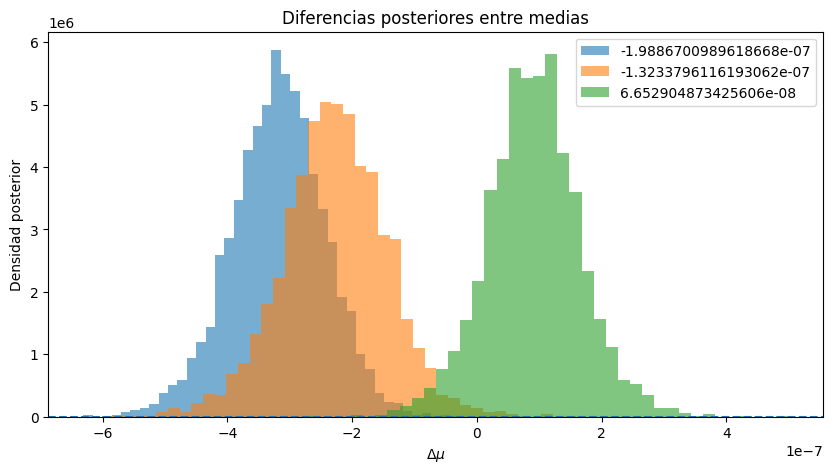

In [81]:
#En la diagonal nos dice  que las distribuciones posteriores son aproximademente
# gaussianas y bien definidas, con mu_s = -1.63e-6, mu_U = -1.40e-6, mu_A = -1.31e-6 e incirtidumbre son
# del orden de e-8.

#Calculamos las diferencias posteriores entre las medias
mu_a=posterior[:,0]
mu_s=posterior[:,2]
mu_u=posterior[:,4]

delta_sa=mu_s-mu_a
delta_su=mu_s-mu_u
delta_au=mu_a-mu_u

#Graficamos

plt.figure(figsize=(10, 5))

plt.hist(delta_sa, bins=40, density=True, alpha=0.6, label=mu_s-mu_a )
plt.hist(delta_su, bins=40, density=True, alpha=0.6, label=mu_s-mu_u)
plt.hist(delta_au, bins=40, density=True, alpha=0.6, label=mu_a-mu_u)

plt.axhline(0, linestyle='--')

plt.xlabel(r"$\Delta \mu$")
plt.ylabel("Densidad posterior")
plt.title("Diferencias posteriores entre medias")

plt.legend()
plt.show()

In [79]:
#En la grafica podemos ver que la figura azul mu_s-mu_a , esta completamente a la izq del cero mu_<mu_a, es decir que existe una probabilidad cercana al 100%
#de que lo sanos sean mas diamagneticos que los ansemicos , la figura naranja mu_s-mu_U , se encuentra igualmente a la izquierda de cero igual una probabilidad
#posterior muy alta de que los sanos sean mas diamagneticos que los autodeclarados y finalmente la figura verde  mu_a-mu_u, la distribucion se centra alrededor
#de 6.6e-8 eso indica que mu_a>mu_u es decir anemic menos diamagnetico que el autodeclarado aunque esa diferencia es mucho menos que las otras y esto es
#exactamente lo que sugeria Mann-Whitney y Welch   es decir no hay una diferencia estadistica, pero existe una tendencia.

#Ahora continuamos calculando las probabilidades posteriores

print("P(mu_sano < mu_anemico) =", np.mean(mu_s < mu_a))
print("P(mu_sano < mu_asume)   =", np.mean(mu_s < mu_u))
print("P(mu_anemico < mu_asume) =", np.mean(mu_a < mu_u))

P(mu_sano < mu_anemico) = 1.0
P(mu_sano < mu_asume)   = 0.9942708333333333
P(mu_anemico < mu_asume) = 0.10260416666666666


In [ ]:
#mu_sano < mu_anemico=100% nos indica que todas las muestras posteriores indican que el grupo sano presenta susceptibilidades
# más diamagnéticas que el grupo anémico.Una evidencia extremadamente fuerte, literalmente el 100% de probabilidad , sobre que
#hay  una diferencia clara entre los valores de suceptibilidad.

#mu_sano < mu_asume= 99.4% es decir ese porcentaje de probabilidad de que el grupo sano sea más diamagnético que el grupo
#autodeclarado sano. Una evidecia tambien fuerte de que exista una diferencia por suceptibilidad.

#mu_anemico < mu_asume= 10.2% sugiere que el grupo autodeclarado sano es ligeramente más diamagnético que el grupo anémico,
#la evidencia es considerablemente más débil que en las otras comparaciones.

#aqui podemos ver para que no servia la inferencia bayesiana mientras que los anslisis estadisticos nos indicaban solo que no
# encontraba evidencia suficiente para afirmar diferencias entre Anémico y Autodeclarado. Mientras que la inferencia bayesiana
# que la mayor parte del posterior nos indica que los auto declarado son ligermente mas diamagneticos que los anemicos, pero
#la evidencia es mucho menor que las invulocradas al grupo sano.


In [86]:
#Calculamos  los intervalosde confianza  para las diferencias posteriores
def resumen_posterior(samples, nombre):

    q025, q16, q50, q84, q975 = np.percentile(
        samples,
        [2.5, 16, 50, 84, 97.5]
    )

    print("\n", nombre)

    print(
        "Mediana = {:.3e}".format(q50)
    )

    print(
        "IC 68% = [{:.3e}, {:.3e}]".format(
            q16,
            q84
        )
    )

    print(
        "IC 95% = [{:.3e}, {:.3e}]".format(
            q025,
            q975
        )
    )


# Tambien las medias que nos de el intervalo
resumen_posterior(mu_a, r'$\mu_{anemico}$')
resumen_posterior(mu_s, r'$\mu_{sano}$')
resumen_posterior(mu_u, r'$\mu_{autodeclarado}$')

# Incluimos en el resumen la diferencia entre medias igual que nos de el intervalo
resumen_posterior(delta_sa, r'$\mu_{sano}-\mu_{anemico}$')
resumen_posterior(delta_su, r'$\mu_{sano}-\mu_{autodeclarado}$')
resumen_posterior(delta_au,  r'$\mu_{anemico}-\mu_{autodeclarado}$')




 $\mu_{anemico}$
Mediana = -1.311e-06
IC 68% = [-1.359e-06, -1.268e-06]
IC 95% = [-1.413e-06, -1.222e-06]

 $\mu_{sano}$
Mediana = -1.631e-06
IC 68% = [-1.684e-06, -1.580e-06]
IC 95% = [-1.749e-06, -1.523e-06]

 $\mu_{autodeclarado}$
Mediana = -1.405e-06
IC 68% = [-1.458e-06, -1.348e-06]
IC 95% = [-1.520e-06, -1.283e-06]

 $\mu_{sano}-\mu_{anemico}$
Mediana = -3.178e-07
IC 68% = [-3.920e-07, -2.453e-07]
IC 95% = [-4.754e-07, -1.767e-07]

 $\mu_{sano}-\mu_{autodeclarado}$
Mediana = -2.272e-07
IC 68% = [-3.061e-07, -1.466e-07]
IC 95% = [-4.008e-07, -6.788e-08]

 $\mu_{anemico}-\mu_{autodeclarado}$
Mediana = 9.090e-08
IC 68% = [2.088e-08, 1.604e-07]
IC 95% = [-6.024e-08, 2.467e-07]


In [ ]:
#Las diferencias entre los grupos sano–anémico y sano–autodeclarado presentan intervalos de confianza al 95% que no incluyen el cero, indicando una separación robusta entre dichas poblaciones.
#Por el contrario, la diferencia entre los grupos anémico y autodeclarado sano presenta un intervalo creíble que incluye el cero, sugiriendo que los datos disponibles no permiten establecer
#una diferencia concluyente entre ambas poblaciones.

# Los resultados bayesianos reproducen las conclusiones obtenidas mediante Mann-Whitney y Welch, pero permite cuantificar directamente la incertidumbre asociada a las diferencias observadas
# mediante distribuciones posteriores e intervalos creíbles.
